In [1]:
cumle = "Öğrenci parkta oturan yaşlı adama nazikçe sorusunu sordu ve cevabını sabırla bekledi"
kelimeler = cumle.split()

kelime_to_id = {kelime: idx for idx, kelime in enumerate(kelimeler)}
tokenlar = [kelime_to_id[kelime] for kelime in kelimeler]

print(f"Toplam kelime sayısı: {len(kelimeler)}")
print("Kelimeler:", kelimeler)
print("Token ID dizisi:", tokenlar)

Toplam kelime sayısı: 12
Kelimeler: ['Öğrenci', 'parkta', 'oturan', 'yaşlı', 'adama', 'nazikçe', 'sorusunu', 'sordu', 've', 'cevabını', 'sabırla', 'bekledi']
Token ID dizisi: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)

vocab_size = len(kelimeler)
embedding_boyutu = 16

embedding_layer = nn.Embedding(vocab_size, embedding_boyutu)
token_tensor = torch.tensor(tokenlar)
embeddings = embedding_layer(token_tensor)

def positional_encoding_olustur(seq_len, d_model):
    pe = torch.zeros(seq_len, d_model)
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            pe[pos, i] = torch.sin(torch.tensor(pos / (10000 ** (i / d_model))))
            pe[pos, i+1] = torch.cos(torch.tensor(pos / (10000 ** (i / d_model))))
    return pe

pos_encoding = positional_encoding_olustur(len(kelimeler), embedding_boyutu)
embeddings_with_pos = embeddings + pos_encoding

print("Embedding boyutu:", embeddings.shape)
print("Konum kodlaması eklenmiş son boyut:", embeddings_with_pos.shape)

Embedding boyutu: torch.Size([12, 16])
Konum kodlaması eklenmiş son boyut: torch.Size([12, 16])


In [3]:
Q = embeddings_with_pos
K = embeddings_with_pos
V = embeddings_with_pos

skorlar = torch.matmul(Q, K.T)
skorlar_olceklendi = skorlar / (embedding_boyutu ** 0.5)
dikkat_agirliklari = F.softmax(skorlar_olceklendi, dim=-1)
sonuc = torch.matmul(dikkat_agirliklari, V)

print("Dikkat ağırlıkları matrisi boyutu:", dikkat_agirliklari.shape)


Dikkat ağırlıkları matrisi boyutu: torch.Size([12, 12])


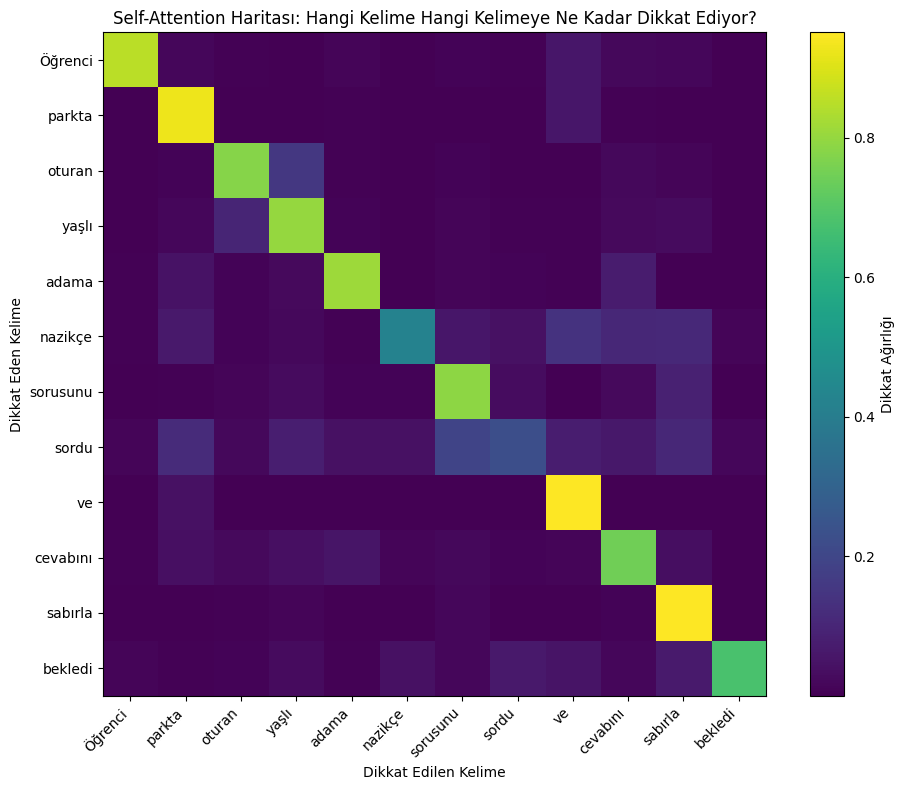

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(dikkat_agirliklari.detach().numpy(), cmap='viridis')

ax.set_xticks(range(len(kelimeler)))
ax.set_yticks(range(len(kelimeler)))
ax.set_xticklabels(kelimeler, rotation=45, ha='right')
ax.set_yticklabels(kelimeler)

plt.colorbar(im, label='Dikkat Ağırlığı')
plt.title('Self-Attention Haritası: Hangi Kelime Hangi Kelimeye Ne Kadar Dikkat Ediyor?')
plt.xlabel('Dikkat Edilen Kelime')
plt.ylabel('Dikkat Eden Kelime')
plt.tight_layout()
plt.show()

In [5]:
multihead_attn = nn.MultiheadAttention(embed_dim=embedding_boyutu, num_heads=4, batch_first=True)

giris = embeddings_with_pos.unsqueeze(0)

attn_output, attn_weights = multihead_attn(giris, giris, giris)

print("Multi-Head Attention çıktı boyutu:", attn_output.shape)
print("Kaç 'kafa' (head) kullanıldı: 4")

Multi-Head Attention çıktı boyutu: torch.Size([1, 12, 16])
Kaç 'kafa' (head) kullanıldı: 4


## 🧩 LLM/Transformer Derinlemesine Örnek — Attention Mekanizması Uygulaması

**Amaç:** Tokenization'dan Multi-Head Attention'a kadar, bir Transformer'ın tüm temel bileşenlerini gerçek kodla, uzun bir cümle üzerinde deneyimlemek.

**Kullanılan cümle:** "Öğrenci parkta oturan yaşlı adama nazikçe sorusunu sordu ve cevabını sabırla bekledi" (11 kelime)

### Adım Adım Yapılanlar

**1. Tokenization** — Cümle kelimelere ayrıldı, her kelimeye benzersiz bir ID atandı.

**2. Embedding** — Her token ID'si, 16 boyutlu bir anlam vektörüne çevrildi (`nn.Embedding` ile).

**3. Positional Encoding** — Sinüs/kosinüs fonksiyonlarıyla, kelimelerin cümledeki konum bilgisi vektörlere eklendi.

**4. Self-Attention (Manuel Hesaplama)** — Query-Key çarpımı, ölçeklendirme, Softmax ve Value ile 11x11'lik bir dikkat ağırlıkları matrisi elle hesaplandı.

**5. Attention Haritası Görselleştirme** — Dikkat ağırlıkları bir ısı haritası (heatmap) olarak çizildi. Köşegen (diagonal) üzerinde en yüksek değerlerin çıktığı gözlemlendi — bunun, modelin henüz eğitilmemiş olmasından (her kelimenin matematiksel olarak kendine en çok benzemesi) kaynaklandığı anlaşıldı.

**6. Multi-Head Attention (PyTorch ile)** — `nn.MultiheadAttention` kullanılarak, 4 farklı "kafa" ile paralel attention hesaplaması yapıldı.

### Öğrenilen Temel Kavramlar

- Tokenization, Embedding, Positional Encoding
- Query / Key / Value ve Softmax ile dikkat ağırlığı hesaplama
- Multi-Head Attention: birden fazla ilişki türüne paralel odaklanma

**Çıkardığım ders:** Elle self-attention hesaplamak, bir Transformer'ın "kara kutu" gibi görünen içini gerçekten şeffaf hale getirdi. Rastgele başlatılan ağırlıklarla anlamlı bir örüntü çıkmasa da (köşegen üzerinde yoğunlaşma bekleniyordu), matematiğin ve akışın nasıl işlediğini adım adım görmek, LLM'lerin temelini kavramamı sağladı.